In [69]:
import pandas as pd
import numpy as np
from collections import deque
import matplotlib.pyplot as plt

## Processing Potentiometer Data

Let's first read the data that are relevant to organize the voltage level according to the time that has passed.

In [70]:
# Step 1: Read data 
# Identify potential value
ec_df = pd.read_csv('./data/Coated_SS-052125_800mV_vs_Ag-AgCl/Coated_SS-052125_800mV_vs_Ag-AgCl.txt', header=None)

row_index = ec_df[ec_df.apply(lambda row: row.astype(str).str.contains('Time/sec').any(), axis=1)].index[0]

ec_df_aux_data = ec_df.iloc[:row_index]

ec_df_cleaned = ec_df.iloc[row_index+1:]

ec_df_cleaned.columns = ['Time/sec', 'Current/A']
ec_df_cleaned.set_index('Time/sec', inplace=True)

ec_df_cleaned['Current/A'] = ec_df_cleaned['Current/A'].astype(float)
ec_df_cleaned



/var/folders/vm/_ljljg3d2ln_x5m_sd3t34kr0000gn/T/ipykernel_66231/2526437381.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ec_df_cleaned['Current/A'] = ec_df_cleaned['Current/A'].astype(float)


,Current/A
Time/sec,
0.000e+0,0.000356
1.000e-1,0.000354
2.000e-1,0.000353
3.000e-1,0.000351
4.000e-1,0.000350
...,...
7.195e+3,0.000266
7.195e+3,0.000266
7.195e+3,0.000266


In [71]:
potential = ec_df_aux_data[
    ec_df_aux_data.apply(lambda row: row.astype(str).str.contains('E (V) =', regex=False).any(), axis=1)
].index[0]

potential = ec_df_aux_data.iloc[potential, 0].split('=')[1].strip()
potential = float(potential)
potential

0.8

In [72]:
# Step 3: Replace intervals at appropriate sections
ec_df_cleaned['Potential/v'] = potential
ec_df_cleaned


/var/folders/vm/_ljljg3d2ln_x5m_sd3t34kr0000gn/T/ipykernel_66231/236758389.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ec_df_cleaned['Potential/v'] = potential


,Current/A,Potential/v
Time/sec,,
0.000e+0,0.000356,0.8
1.000e-1,0.000354,0.8
2.000e-1,0.000353,0.8
3.000e-1,0.000351,0.8
4.000e-1,0.000350,0.8
...,...,...
7.195e+3,0.000266,0.8
7.195e+3,0.000266,0.8
7.195e+3,0.000266,0.8


## Cleaning ICP-MS Data


To align these data we take into account three externally measured variables: 

* Potential Calibration of the Reference Electrode (PCRE) with respect to Reversible Hydrogen Electrode (RHE): `potent_calib`

* the difference between the E-Chem and the ICP-MS start times: `del_start`

* the Response Delay which indicates the difference in which some electrochemical event occurs and when it is recorded within the ICP-MS: `response_delay`


To begin, let's clean the EChem data and offset the echem data by the PCRE and store it in its respective array.

In [73]:
''' 
Values used in Matt Sweers' parameter template file
'''

potent_calib = .268 
del_start = 108
response_delay = 23

In [74]:
ec_cal = ec_df_cleaned.copy()
ec_cal['Current/A'] = ec_cal['Current/A'] + potent_calib  # Apply calibration

ec_cal


,Current/A,Potential/v
Time/sec,,
0.000e+0,0.268356,0.8
1.000e-1,0.268354,0.8
2.000e-1,0.268353,0.8
3.000e-1,0.268351,0.8
4.000e-1,0.268350,0.8
...,...,...
7.195e+3,0.268266,0.8
7.195e+3,0.268266,0.8
7.195e+3,0.268266,0.8


In [75]:
icp_df = pd.read_csv('./data/Coated_SS-052125_800mV_vs_Ag-AgCl/GM_Coated_SS_052125.csv')

ICP-MS and E-Chem often exhibit different shapes as the data are collected in a distinct fashions. For example in `400_mV_041725.csv`, the ICP-MS dataset is of shape ($\text{columns} \times \text{rows}$) $90711 \times 6$ whereas the E-Chem dataframes is $221106 \times 3$. This necessitates truncation of the larger dataset to best fit the smaller counterpart.

In addition, we offset the time values by the appropriate amount by subtracting the sum of the start and response delay `del_start` + `response_delay`.

In [76]:
# Cut off ICP-MS data before the E-Chem data begins population
icp_trunc = icp_df[icp_df['Time'] >(del_start+response_delay)]

# Shift time so that it starts from zero relative to E-Chem
icp_trunc['Time'] = icp_trunc['Time']-(del_start+response_delay)

# Keep a NumPy copy
icp_trunc_np = icp_trunc.to_numpy()

/var/folders/vm/_ljljg3d2ln_x5m_sd3t34kr0000gn/T/ipykernel_66231/3466582724.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  icp_trunc['Time'] = icp_trunc['Time']-(del_start+response_delay)


In [77]:
icp_trunc

,Replicate,Reading,Time,Ti -/48(Pulse/CPS),Cr -/52(Pulse/CPS),Mn -/55(Pulse/CPS),Fe -/56(Pulse/CPS),Ni -/60(Pulse/CPS),Mo -/98(Pulse/CPS)
304,1,305,0.332,40.000056,180.001134,60.000126,10884.144682,1520.080868,140.000686
305,1,306,0.764,40.000056,120.000504,0.000000,11164.360799,1760.108423,180.001134
306,1,307,1.196,20.000014,140.000686,20.000014,11084.298491,1760.108423,120.000504
307,1,308,1.628,0.000000,220.001694,0.000000,11644.744069,1720.103550,200.001400
308,1,309,2.060,0.000000,80.000224,20.000014,11524.646738,1880.123712,100.000350
...,...,...,...,...,...,...,...,...,...
42560,1,42561,18255.601,80.000224,140.000686,0.000000,9903.431539,1940.131735,0.000000
42561,1,42562,18256.033,20.000014,180.001134,40.000056,11644.744069,1780.110901,40.000056
42562,1,42563,18256.465,0.000000,140.000686,0.000000,11544.662889,2020.142824,0.000000
42563,1,42564,18256.897,20.000014,160.000896,100.000350,12085.109584,1680.098790,40.000056


# Interpolation
The `final_dataset` will indicate the result of the last two steps and this one: interpolation. The goal is to linearly interpret values $t_1, t_2$, the times before and after any given ICP-MS datapoint being mapped to the E-Chem data defined as $t$. The interpolated potential $\left(E(t)\right)$ and current density $\left(i(t)\right)$ at $t$ can be obtained the following two equations:

$$E(t) = E_0 + \left( \frac{t-t_0}{t_1 - t_0} \right) \left(E_1 - E_0\right)$$

$$i(t) = i_0 + \left( \frac{t-t_0}{t_1 - t_0} \right) \left(i_1 - i_0\right)$$

In [78]:
# Assume icp_trunc has columns: ['Time', 'ICP_MS_Signal']
ec_times = ec_cal.index.astype(float)
ec_voltages = ec_cal['Potential/v'].values
ec_currents = ec_cal['Current/A'].values

fin = []

for i in range(len(icp_trunc)):
    fin_t = icp_trunc.iloc[i]['Time']

    idx = np.searchsorted(ec_times, fin_t)

    if idx == 0:
        interp_voltage = ec_voltages[0]
        interp_current = ec_currents[0]
    elif idx >= len(ec_times):
        interp_voltage = ec_voltages[-1]
        interp_current = ec_currents[-1]
    else:
        t0, t1 = ec_times[idx - 1], ec_times[idx]
        v0, v1 = ec_voltages[idx - 1], ec_voltages[idx]
        c0, c1 = ec_currents[idx - 1], ec_currents[idx]

        interp_voltage = v0 + (fin_t - t0) * (v1 - v0) / (t1 - t0)
        interp_current = c0 + (fin_t - t0) * (c1 - c0) / (t1 - t0)

    fin.append([fin_t, interp_voltage, interp_current])

fin_df = pd.DataFrame(fin, columns=['Time', 'Potential/v', 'Current/A_(interp\'d)'])

# Drop unwanted columns from icp_trunc and reset index
extra_cols = icp_trunc.drop(columns=['Replicate', 'Reading', 'Time'], errors='ignore').reset_index(drop=True)

# Concatenate the two DataFrames column-wise
fin_df = pd.concat([extra_cols, fin_df], axis=1)

fin_df = fin_df.set_index('Time')
fin_df



,Ti -/48(Pulse/CPS),Cr -/52(Pulse/CPS),Mn -/55(Pulse/CPS),Fe -/56(Pulse/CPS),Ni -/60(Pulse/CPS),Mo -/98(Pulse/CPS),Potential/v,Current/A_(interp'd)
Time,,,,,,,,
0.332,40.000056,180.001134,60.000126,10884.144682,1520.080868,140.000686,0.8,0.268351
0.764,40.000056,120.000504,0.000000,11164.360799,1760.108423,180.001134,0.8,0.268346
1.196,20.000014,140.000686,20.000014,11084.298491,1760.108423,120.000504,0.8,0.268341
1.628,0.000000,220.001694,0.000000,11644.744069,1720.103550,200.001400,0.8,0.268337
2.060,0.000000,80.000224,20.000014,11524.646738,1880.123712,100.000350,0.8,0.268334
...,...,...,...,...,...,...,...,...
18255.601,80.000224,140.000686,0.000000,9903.431539,1940.131735,0.000000,0.8,0.268266
18256.033,20.000014,180.001134,40.000056,11644.744069,1780.110901,40.000056,0.8,0.268266
18256.465,0.000000,140.000686,0.000000,11544.662889,2020.142824,0.000000,0.8,0.268266


In [79]:
#   <!-- We can convert this to $\frac{\mu \text{g}}{\text{hr} \cdot \text{cm}^2}$ by multiplying the parts per billion (ppb) $\left(\mu \text{g}/\text{hr}\right)$ by $\frac{\text{flow rate}}{\text{exposed area}}$ to get $\text{L/hr}$. -->

# flow_rate = .387
# exposed_area = 2.68

# ppb_conversion_rate = 16928
# # fin_df['ICP_MS (Cr)/ppb'] = fin_df['ICP_MS (Cr)']/ppb_conversion_rate
# # =(C3*0.001*0.387*60)/2.68

# # fin_df['Cr-ug/(hr*cm2)'] = fin_df['ICP_MS (Cr) ppb']*(1/1000)*(60)*(flow_rate/exposed_area)
# # Convert to g
# # Convert to hours

# fin_df

/var/folders/vm/_ljljg3d2ln_x5m_sd3t34kr0000gn/T/ipykernel_66231/875292628.py:21: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


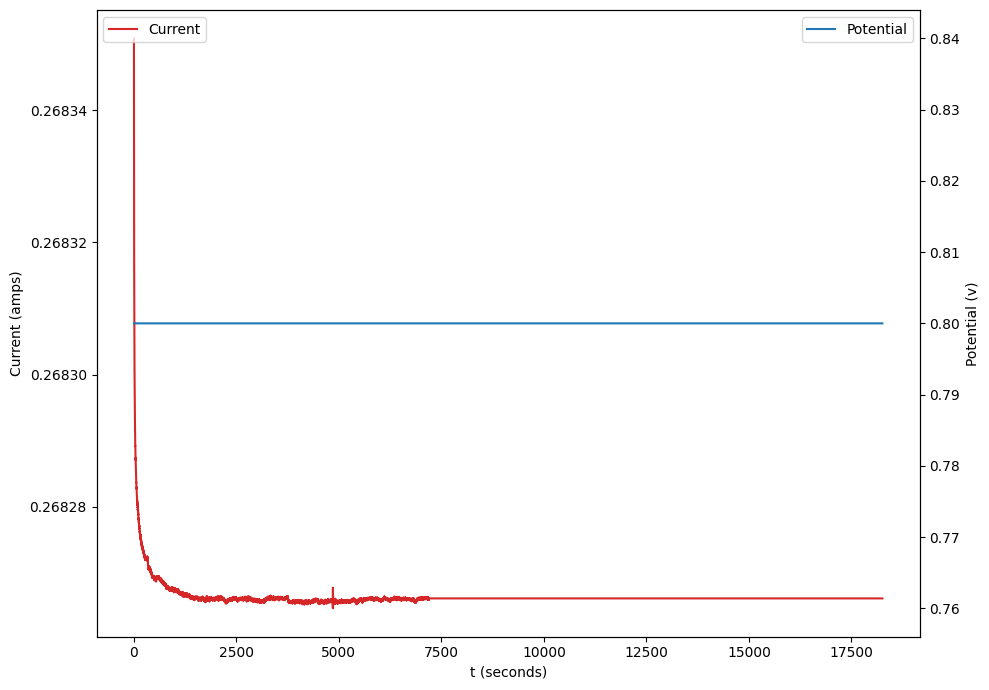

In [80]:
x = np.linspace(0,2,100)

t = fin_df.index
current = fin_df['Current/A_(interp\'d)']
potential = fin_df['Potential/v']

fig, ax1 = plt.subplots(figsize=(10, 7), layout='constrained')


color = 'tab:red'
ax1.set_xlabel('t (seconds)')
ax1.plot(t, current, label='Current', color=color)
ax1.set_ylabel('Current (amps)')
ax1.legend(loc='upper left')

color = 'tab:blue'
ax2 = ax1.twinx()
ax2.set_ylabel('Potential (v)')
ax2.plot(t, potential, label='Potential', color=color)

fig.tight_layout()
ax2.legend(loc='upper right')
